<a href="https://colab.research.google.com/github/Zhr-Srj/TripSimAcin-AMR/blob/main/Code/KEGG_validation1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In this notebook I want to compare our model with traditional machine learning models, on KEGG-selected genes (96 + 881 drug features), 5 times and report the results in the form of average over results of these 5 times.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Required packages

In [ ]:
pip install xgboost

In [ ]:
import sys
import gc

import csv
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import random
from random import sample, shuffle

from sklearn.utils import shuffle as sk_shuffle

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix, accuracy_score, f1_score
from sklearn.model_selection import KFold

from tensorflow.keras.layers import Input, Dense, Dropout, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import LayerNormalization
from tensorflow.keras.callbacks import  History

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost

# Data prepation

## Loading train-test dataset

In [ ]:
with open(r'/content/drive/MyDrive/Master_new_Sep/Revise/Dataset_KEGG_u.txt') as f:
    orig_data = []
    for line in f.readlines():
        row = []
        for elem in line.split(sep=','):
            row.append(int(elem.strip()))
        orig_data.append(row)
print(len(orig_data))
print(len(orig_data[0]))

407
977


In [ ]:
#Reading phenotypes file
with open(r'/content/drive/MyDrive/Master_new_Sep/Revise/DrugLabel_KEGG_u.txt') as fy:
    orig_labels = []
    drugs = [] #stores drug name in each row
    row = 0 # row number of each label (is needed because data is reordered while spliting)
    reader = csv.reader(fy)
    for i in reader:
        orig_labels.append([row, int(i[1])])
        drugs.append(i[0])
        row += 1

print(len(orig_labels))
print(len(drugs))
print(orig_labels[:5])

407
407
[[0, 1], [1, 0], [2, 0], [3, 1], [4, 1]]


In [ ]:
orig_labels = np.asarray(orig_labels)

### A survey on data

In [ ]:
unq_drugs = set(drugs)
len(unq_drugs)

12

In [ ]:
per_drug_dic = {}
for i in orig_labels:
  drug = drugs[i[0]]
  label = i[1]
  if drug not in per_drug_dic.keys():
    per_drug_dic[drug] = [0, 0]  # num of resistant, num of susceptible
  if label == 0:
    per_drug_dic[drug][1] += 1
  else:
    per_drug_dic[drug][0] += 1

per_drug_dic

{'ciprofloxacin': [49, 7],
 'doripenem': [4, 11],
 'gentamicin': [30, 6],
 'tetracycline': [34, 14],
 'cefotaxime': [39, 2],
 'meropenem': [6, 14],
 'imipenem': [12, 27],
 'amikacin': [17, 20],
 'levofloxacin': [29, 8],
 'ceftriaxone': [36, 0],
 'ceftazidime': [35, 4],
 'moxifloxacin': [1, 2]}

## Train-Test split

In [ ]:
def balanced_train_test_split(data, labels, drugs, n, rs):
  """
  Performs a train_test_split, setting n susceptibles and n resistant strains aside for each drug
  returns x_train, x_test, y_train, y_test
  """

  data, labels = sk_shuffle(data, labels, random_state=rs)

  x_train = []
  x_test = []
  y_train = []
  y_test = []

  idx = {} # A dic containig indices of susceptible and resistant strain
            # for each drug

  unq_drugs = list(set(drugs))

  for drug_name in unq_drugs:
    if drug_name == 'moxifloxacin' or drug_name == 'ceftriaxone':
      continue

    drug_indx_S = []
    drug_indx_R = []

    for i in range(len(labels)):
      j, l = labels[i][0], labels[i][1]
      if drugs[j] == drug_name:
        if l == 0:
          drug_indx_S.append(i)
        else:
          drug_indx_R.append(i)

    idx[(drug_name, 'S')] = drug_indx_S
    idx[(drug_name, 'R')] = drug_indx_R

  len_xtrain = 0
  len_xtest = 0

  for drug in unq_drugs:

    if drug == 'moxifloxacin' or drug == 'ceftriaxone':
      continue

    num = min(len(idx[(drug, 'S')]), len(idx[(drug, 'R')]))
    if num < 2*n:
      num = int(num/2)
    else:
      num = n

    s_set = idx[(drug, 'S')]
    for i in range(len(s_set)-num):
      x_train.append(data[s_set[i]])
      y_train.append(labels[s_set[i]])
    for i in range(1, num+1):
      x_test.append(data[s_set[-i]])
      y_test.append(labels[s_set[-i]])

    r_set = idx[(drug, 'R')]
    for i in range(len(r_set)-num):
      x_train.append(data[r_set[i]])
      y_train.append(labels[r_set[i]])
    for i in range(1, num+1):
      x_test.append(data[r_set[-i]])
      y_test.append(labels[r_set[-i]])

    print(len(s_set), len(r_set))

    # For confirming it's working properly
    print("for drug ", drug, "# of train samples: ", len(x_train)-len_xtrain )
    len_xtrain = len(x_train)
    print("for drug ", drug, "# of test samples: ", len(x_test)-len_xtest )
    len_xtest = len(x_test)

  return x_train, x_test, y_train, y_test

In [ ]:
def make_balanced_triplets(samples, labels, drugs, num):
  """For each drug in drugs samples...
  makes:
  - n triplets which are both Susceptible to drug (S, S)
  - n triplets which are (R, R)
  - n triplets which are (S, R)
  - n triplets which are (R, S)
  """
  bac_shape = 96

  idx = {} # A dic containig indices of susceptible and resistant strain
            # for each drug

  triplet = [] # Made from samples which are not part of external_test_sets
  triLabels = [] # Labels corresponding to triplets

  unq_drugs = list(set(drugs))

  for drug_name in unq_drugs:

    if drug_name == 'moxifloxacin' or drug_name == 'ceftriaxone':
      continue

    drug_indx_S = []
    drug_indx_R = []
    for i in range(len(labels)):
      j, l = labels[i][0], labels[i][1]
      if drugs[j] == drug_name:
        if l == 0:
          drug_indx_S.append(i)
        else:
          drug_indx_R.append(i)
    idx[(drug_name, 'S')] = drug_indx_S
    idx[(drug_name, 'R')] = drug_indx_R

  for drug in unq_drugs:
    if drug == 'moxifloxacin' or drug == 'ceftriaxone':
      continue

    s_len = len(idx[(drug, 'S')])
    r_len = len(idx[(drug, 'R')])
    n = min(num, int(s_len*(s_len-1)/2), int(r_len*(r_len-1)/2))

    ss = [(i, j) for i in idx[(drug, 'S')] for j in idx[(drug, 'S')] if j>i]
    # ss_sampled = sample(ss, n)

    rr = [(i, j) for i in idx[(drug, 'R')] for j in idx[(drug, 'R')] if j>i]
    # rr_sampled = sample(rr, n)

    rs_temp = [(i, j) for i in idx[(drug, 'R')] for j in idx[(drug, 'S')]]
    # neg_samples = sample(rs, 2*n)
    rs = rs_temp[:n]
    sr = [(t[1], t[0]) for t in rs_temp[n:]]

    for k in range(len(ss)):
      # Making (S, S, d) triplets
      triplet.append( samples[ss[k][0]][:bac_shape] + samples[ss[k][1]][:bac_shape] +
                        samples[ss[k][0]][bac_shape:] )
      triLabels.append([1, 0]) # 1: both phenos the same. First: 0, sencond? --> 0

    for k in range(len(rr)):
      # Making (R, R, d) triplets
      triplet.append( samples[rr[k][0]][:bac_shape] + samples[rr[k][1]][:bac_shape] +
                        samples[rr[k][0]][bac_shape:] )
      triLabels.append([1, 1]) # 1: both phenos the same. First: 1, sencond? --> 1

    for k in range(len(rs)):
      # Making (R, S, d) triplets
      triplet.append( samples[rs[k][0]][:bac_shape] + samples[rs[k][1]][:bac_shape] +
                         samples[rs[k][0]][bac_shape:])
      triLabels.append([0, 1]) # 0: phenos different. First: 1, sencond? --> 0

    for k in range(len(sr)):
      # Making (S, R, d) triplets
      triplet.append( samples[sr[k][0]][:bac_shape] + samples[sr[k][1]][:bac_shape] +
                         samples[sr[k][0]][bac_shape:])
      triLabels.append([0, 0]) # 0: phenos different. First: 0, sencond? --> 1

  return np.array(triplet), np.array(triLabels)

In [ ]:
# Splitting data
train_set, test_set, train_labels, test_labels = balanced_train_test_split(orig_data, orig_labels, drugs, 5, 42)

20 17
for drug  amikacin # of train samples:  27
for drug  amikacin # of test samples:  10
8 29
for drug  levofloxacin # of train samples:  29
for drug  levofloxacin # of test samples:  8
27 12
for drug  imipenem # of train samples:  29
for drug  imipenem # of test samples:  10
11 4
for drug  doripenem # of train samples:  11
for drug  doripenem # of test samples:  4
6 30
for drug  gentamicin # of train samples:  30
for drug  gentamicin # of test samples:  6
2 39
for drug  cefotaxime # of train samples:  39
for drug  cefotaxime # of test samples:  2
14 34
for drug  tetracycline # of train samples:  38
for drug  tetracycline # of test samples:  10
7 49
for drug  ciprofloxacin # of train samples:  50
for drug  ciprofloxacin # of test samples:  6
4 35
for drug  ceftazidime # of train samples:  35
for drug  ceftazidime # of test samples:  4
14 6
for drug  meropenem # of train samples:  14
for drug  meropenem # of test samples:  6


In [ ]:
triplet, pairedLabels =  make_balanced_triplets(train_set, train_labels, drugs, 400)

In [ ]:
print(len(triplet))
print(len(triplet[0]))
print(len(pairedLabels))
print(pairedLabels[0])

5008
1073
5008
[1 0]


In [ ]:
train_labels = np.asarray(train_labels)
pairedLabels = np.asarray(pairedLabels)

# Evaluation functions

In [ ]:
def evaluation(true_labels, pred_labels):

  Dis_pred = []
  for i in pred_labels:
    if i < 0.5:
      Dis_pred.append(0)
    else:
      Dis_pred.append(1)

  acc = accuracy_score(true_labels, Dis_pred)
  auc = roc_auc_score(true_labels, Dis_pred)
  print('Accuracy: ', acc)
  print('ROC-AUC: ', auc)

  TN, FP, FN, TP = confusion_matrix(true_labels, Dis_pred, labels=[0, 1]).ravel()
  sen = TP/(TP+FN)
  spc = TN/(TN+FP)
  print("Sensitivity: ", sen)
  print('Specificity: ', spc)

  conf_matrix = confusion_matrix(true_labels, Dis_pred, labels=[0, 1])
  plt.figure(figsize=(4, 4))
  sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
              xticklabels=['Predicted Negative', 'Predicted Positive'],
              yticklabels=['True Negative', 'True Positive'])
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.title('Confusion Matrix')
  plt.show()

  return acc, auc, sen, spc

# Deep model architecture

In [ ]:
def create_siamese_model(input_shape1, input_shape2, input_shape3):

    right_input = Input(shape=input_shape2)
    left_input = Input(shape=input_shape1)
    third_input = Input(shape=input_shape3)

    shared_layer1 = Dense(64, activation='leaky_relu')
    shared_layer2 = Dense(32, activation='leaky_relu')
    shared_layer3 = Dense(16, activation='leaky_relu')
    shared_bn = BatchNormalization() # shared batch normalization layer
    drug_bn = BatchNormalization() # drug batch normalization layer

    encoded_l = shared_layer1(left_input)
    encoded_l = Dropout(0.2)(encoded_l)
    encoded_l = shared_layer2(encoded_l)
    encoded_l = Dropout(0.2)(encoded_l)
    encoded_l = shared_layer3(encoded_l)
    encoded_l = Dropout(0.2)(encoded_l)
    encoded_l = shared_bn(encoded_l)

    encoded_r = shared_layer1(right_input)
    encoded_r = Dropout(0.2)(encoded_r)
    encoded_r = shared_layer2(encoded_r)
    encoded_r = Dropout(0.2)(encoded_r)
    encoded_r = shared_layer3(encoded_r)
    encoded_r = Dropout(0.2)(encoded_r)
    encoded_r = shared_bn(encoded_r)

    encoded_c = Dense(512, activation='leaky_relu')(third_input)
    encoded_c = Dropout(0.2)(encoded_c)
    encoded_c = Dense(256, activation='leaky_relu')(encoded_c)
    encoded_c = Dropout(0.2)(encoded_c)
    encoded_c = Dense(32, activation='leaky_relu')(encoded_c)
    encoded_c = Dropout(0.2)(encoded_c)
    encoded_c = drug_bn(encoded_c)

    concatenated = Concatenate()([encoded_l, encoded_r, encoded_c])

    dense1 = Dense(32, activation='leaky_relu')(concatenated)
    dense1 = Dropout(0.2)(dense1)
    dense2 = Dense(16, activation='leaky_relu')(dense1)
    dense2 = Dropout(0.2)(dense2)
    prediction = Dense(1, activation='sigmoid')(dense2)

    siamese_net = Model(inputs=[left_input, right_input, third_input], outputs=prediction)

    optimizer = Adam(learning_rate=0.001)
    siamese_net.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=["accuracy", AUC(name='auc-roc')])

    return siamese_net

# Evaluations

## Functions
Performance on queries

So each label is a list of size 2

In [ ]:
def ExternalTest(x0_test,x1_test,x0_train,x1_train):
  """
  Takes as input paired data and
  makes each test sample pair with train samples of the same drug (triplet --> b1, b2, d).
  x0_test: test samples with phenotype 0
  x1_test: test samples with phenotype 1
  x0_train: train samples with phenotype 0
  x1_train: train samples with phenotype 1
  """
  dataset_test1=[] # concat train
  label_test1=[]
  Indexsample=[]

  for i in range(len(x0_test)):
    for j in range(len(x0_train)):
      if (x0_test[i][96:] == x0_train[j][96:]).all():
        dataset_test1.append(np.concatenate((x0_test[i][0:96],x0_train[j]), axis=None))
        label_test1.append(1)
        Indexsample.append(str(i)+",0,0")   #index in test, x0_test pheno, x0_train pheno

  for i in range(len(x0_test)):
    for j in range(len(x1_train)):
      if (x0_test[i][96:] == x1_train[j][96:]).all():
        dataset_test1.append(np.concatenate((x0_test[i][0:96],x1_train[j]), axis=None))
        label_test1.append(0)
        Indexsample.append(str(i)+",0,1")   #index in test, x0_test pheno, x1_train pheno


  for i in range(len(x1_test)):
    for j in range(len(x0_train)):
      if (x1_test[i][96:] == x0_train[j][96:]).all():
        dataset_test1.append(np.concatenate((x1_test[i][0:96],x0_train[j]), axis=None))
        label_test1.append(0)
        Indexsample.append(str(i)+",1,0")  #index in test,x1_test,x0_train


  for i in range(len(x1_test)):
    for j in range(len(x1_train)):
      if (x1_test[i][96:] == x1_train[j][96:]).all():
        dataset_test1.append(np.concatenate((x1_test[i][0:96],x1_train[j]), axis=None))
        label_test1.append(1)
        Indexsample.append(str(i)+",1,1")  #index in test,x1_test,x1_train

  return (np.asarray(dataset_test1), np.asarray(label_test1), Indexsample)

In [ ]:
def DefineTest2(x0_test, x1_test, Indexsample, y_pred):
  Pred=[]
  Label=[]

  # START of x0_test
  for i in range(len(x0_test)):
    cnt0Pred=0
    cnt1Pred=0
    cnt1=0
    cnt0=0

    for j in range(len(Indexsample)):
      triplet=Indexsample[j].split(",")   #pair[0] is index from test, pair[1] identifies which test x0_test or s1_test, pair[2] identifies which x0
      if int(triplet[0])==i: #index test
        if int(triplet[1])==0: #type test

          if int(triplet[2])==1: #type train
              cnt1Pred=cnt1Pred+y_pred[j]
              cnt1=cnt1+1

          if int(triplet[2])==0: #type train
              cnt0Pred=cnt0Pred+y_pred[j]
              cnt0=cnt0+1

    pos=(1-(cnt0Pred/cnt0))+(cnt1Pred/cnt1)
    neg=(cnt0Pred/cnt0)+(1-(cnt1Pred/cnt1))
    Pred.append(pos/(pos+neg))
    Label.append(0)

  # END of x0_test
  ######################################################
  # START of x1_test
  for i in range(len(x1_test)):
    cnt0Pred=0
    cnt1Pred=0
    cnt1=0
    cnt0=0
    for j in range(len(Indexsample)):
      triplet=Indexsample[j].split(",")   #pair[0] is index from test, pair[1] identifies which test x0_test or s1_test, pair[2] identifies which x0
      if int(triplet[0])==i: #index test
        if int(triplet[1])==1: #type test

          if int(triplet[2])==0: #type train
              cnt0Pred=cnt0Pred+y_pred[j]
              cnt0=cnt0+1

          if int(triplet[2])==1: #type train
              cnt1Pred=cnt1Pred+y_pred[j]
              cnt1=cnt1+1

    pos=(1-(cnt0Pred/cnt0))+(cnt1Pred/cnt1)
    neg=(cnt0Pred/cnt0)+(1-(cnt1Pred/cnt1))
    Pred.append(pos/(pos+neg))
    Label.append(1)

  return(Pred,Label)

In [ ]:
def RS_splitter(data, labels):
  """
  Takes as input a dataset and corresponding labels (in terms of list of 0s and 1s)
  returns data0, data1
  which are set of susceptible and resistant strains in data, respectively
  """
  data0 = [] # list of susceptible strains' features
  data1 = [] # list of resistant strains' features

  for i, l in enumerate(labels):
    if l == 0:
      data0.append(data[i])
    else:
      data1.append(data[i])

  return data0, data1

In [ ]:
rf_acc = []
rf_auc = []
rf_sen = []
rf_spc = []

svm_acc = []
svm_auc = []
svm_sen = []
svm_spc = []

xgb_acc = []
xgb_auc = []
xgb_sen = []
xgb_spc = []

nn_acc = []
nn_auc = []
nn_sen = []
nn_spc = []

sim_acc = []
sim_auc = []
sim_sen = []
sim_spc = []

# Round 1
random state 42

### Training

#### Random Forest (RF)

In [ ]:
model = RandomForestClassifier(n_estimators=100).fit(train_set, train_labels[:, 1])
predict_RF = model.predict(test_set)

#### SVM

In [ ]:
model = SVC(kernel='poly').fit(train_set, train_labels[:, 1])
predict_SVM = model.predict(test_set)

#### XGBoost

In [ ]:
model = xgboost.XGBClassifier().fit(train_set, train_labels[:, 1])
predict_XGB = model.predict(test_set)

#### Triplet NN

In [ ]:
input_shape1 = (96,)
input_shape2 = (96,)
input_shape3 = (881,)

In [ ]:
siamese_net = create_siamese_model(input_shape1, input_shape2, input_shape3)

In [ ]:
triplet = np.asarray(triplet)

In [ ]:
triplet.shape

(5008, 1073)

In [ ]:
pairedLabels = np.asarray(pairedLabels)

In [ ]:
pairedLabels.shape

(5008, 2)

In [ ]:
num_epochs=10
history=History()
siamese_net = create_siamese_model(input_shape1, input_shape2, input_shape3)

print("Round: 1 ---> 1-10")
history = siamese_net.fit([[triplet[:, :96],
                           triplet[:, 96:(96+96)]],
                           triplet[:, (96+96):]], pairedLabels[:, 0],
                          epochs=num_epochs, batch_size=64, verbose=1, callbacks=history)

for i in range(20-1):
  print("Round: ", i+2, '--->', (i+1)*10+1, '-', (i+2)*10)

  triplet, pairedLabels =  make_balanced_triplets(train_set, train_labels, drugs, 400)

  history = siamese_net.fit([[triplet[:, :96],
                           triplet[:, 96:(96+96)]],
                           triplet[:, (96+96):]], pairedLabels[:, 0],
                          epochs=num_epochs, batch_size=64, verbose=1, callbacks=history)


In [ ]:
train_pred = siamese_net.predict([[triplet[:, :96],
                           triplet[:, 96:(96+96)]],
                           triplet[:, (96+96):]])

Accuracy:  0.9215255591054313
ROC-AUC:  0.8679261039994748
Sensitivity:  0.9645517595684562
Specificity:  0.7713004484304933


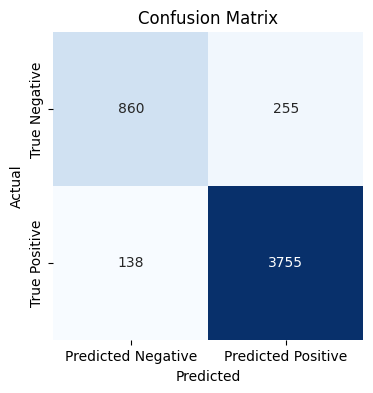

(0.9215255591054313,
 np.float64(0.8679261039994748),
 np.float64(0.9645517595684562),
 np.float64(0.7713004484304933))

In [ ]:
# Similarity test for train_set
evaluation(pairedLabels[:, 0], train_pred)

## validation

#### RF

In [ ]:
test_labels = np.asarray(test_labels)

Accuracy:  0.45454545454545453
ROC-AUC:  0.4545454545454546
Sensitivity:  0.8181818181818182
Specificity:  0.09090909090909091


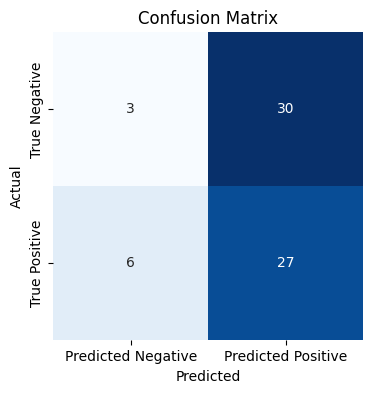

In [ ]:
acc, auc, sen, spc = evaluation(test_labels[:, 1], predict_RF)

In [ ]:
rf_acc.append(acc)
rf_auc.append(auc)
rf_sen.append(sen)
rf_spc.append(spc)

In [ ]:
print(rf_acc)
print(rf_auc)
print(rf_sen)
print(rf_spc)

[0.45454545454545453]
[np.float64(0.4545454545454546)]
[np.float64(0.8181818181818182)]
[np.float64(0.09090909090909091)]


#### SVM

Accuracy:  0.5
ROC-AUC:  0.5
Sensitivity:  1.0
Specificity:  0.0


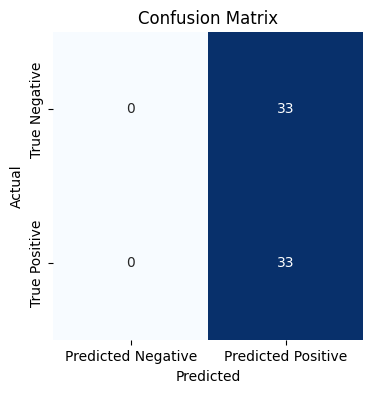

In [ ]:
acc, auc, sen, spc = evaluation(test_labels[:, 1], predict_SVM)

In [ ]:
svm_acc.append(acc)
svm_auc.append(auc)
svm_sen.append(sen)
svm_spc.append(spc)

In [ ]:
print(svm_acc)
print(svm_auc)
print(svm_sen)
print(svm_spc)

[0.5]
[np.float64(0.5)]
[np.float64(1.0)]
[np.float64(0.0)]


#### XGBoost

Accuracy:  0.4696969696969697
ROC-AUC:  0.4696969696969697
Sensitivity:  0.8181818181818182
Specificity:  0.12121212121212122


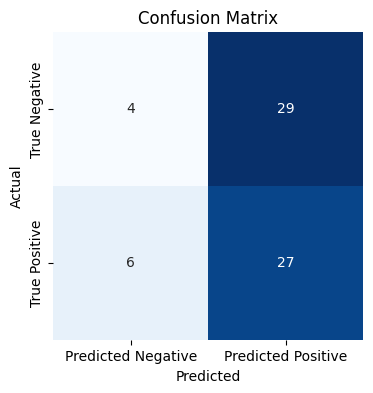

In [ ]:
acc, auc, sen, spc = evaluation(test_labels[:, 1], predict_XGB)

In [ ]:
xgb_acc.append(acc)
xgb_auc.append(auc)
xgb_sen.append(sen)
xgb_spc.append(spc)

In [ ]:
print(xgb_acc)
print(xgb_auc)
print(xgb_sen)
print(xgb_spc)

[0.4696969696969697]
[np.float64(0.4696969696969697)]
[np.float64(0.8181818181818182)]
[np.float64(0.12121212121212122)]


#### Triplet NN

In [ ]:
test_labels = np.asarray(test_labels)
train_labels = np.asarray(train_labels)

In [ ]:
# splitting external_test_set to set of susceptible and resistant ones:
x0_test, x1_test = RS_splitter(test_set, test_labels[:, 1])

In [ ]:
print(len(x0_test))
print(len(x0_test[0]))
print(len(x1_test))
print(len(x1_test[0]))

33
977
33
977


In [ ]:
x0_train, x1_train = RS_splitter(train_set, train_labels[:, 1])

In [ ]:
print(len(x0_train))
print(len(x0_train[0]))
print(len(x1_train))
print(len(x1_train[0]))

80
977
222
977


In [ ]:
x0_train = np.asarray(x0_train)
x1_train = np.asarray(x1_train)

In [ ]:
test_labels = []  # True labels for test samples.
aggre_preds = [] # Aggregated pred values for each sample, by DefineTest2 func.
internal_labels = [] # Labels form ExternalTest2 for internal test
internal_preds = [] # internal_labels corresponding predictions


for i in x0_test:                     #x0_test, x1_test, x0_train, x1_train
  data, labels, indexSample = ExternalTest([i], [], x0_train, x1_train) # makes i couple with x0_train & x1_train
  internal_labels += labels.tolist()
  predd = siamese_net.predict([[data[:, :96],
                           data[:, 96:(96+96)]],
                           data[:, (96+96):]], verbose=0)
  internal_preds += [i[0] for i in predd.tolist()]
  y_pred, label = DefineTest2([i], [], indexSample, predd)
  aggre_preds.append(y_pred[0][0]) # y_pred ---> [array([0.5], dtype=float32)]
  test_labels.append(label[0])


for i in x1_test:
  data, labels, indexSample = ExternalTest([], [i], x0_train, x1_train)
  internal_labels += labels.tolist()
  predd = siamese_net.predict([[data[:, :96],
                           data[:, 96:(96+96)]],
                           data[:, (96+96):]], verbose=0)
  internal_preds += [i[0] for i in predd.tolist()]
  y_pred, label = DefineTest2([], [i], indexSample, predd)
  aggre_preds.append(y_pred[0][0])
  test_labels.append(label[0])

##### TSA_Net evaluation

(Similarity test)

Accuracy:  0.5121675155631012
ROC-AUC:  0.5014884233737597
Sensitivity:  0.9029768467475193
Specificity:  0.1


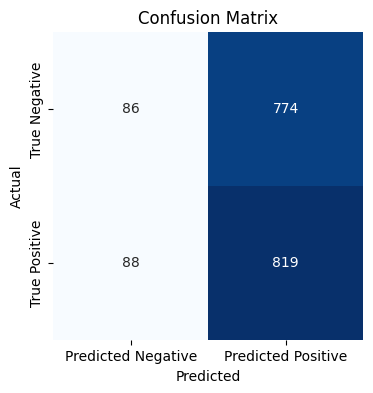

In [ ]:
acc, auc, sen, spc = evaluation(internal_labels, internal_preds)

In [ ]:
sim_acc.append(acc)
sim_auc.append(auc)
sim_sen.append(sen)
sim_spc.append(spc)

In [ ]:
print(sim_acc)
print(sim_auc)
print(sim_sen)
print(sim_spc)

[0.5121675155631012]
[np.float64(0.5014884233737597)]
[np.float64(0.9029768467475193)]
[np.float64(0.1)]


##### TripSimAcin_AMR evaluation

(Phenotype prediction test)

Accuracy:  0.5454545454545454
ROC-AUC:  0.5454545454545454
Sensitivity:  0.5454545454545454
Specificity:  0.5454545454545454


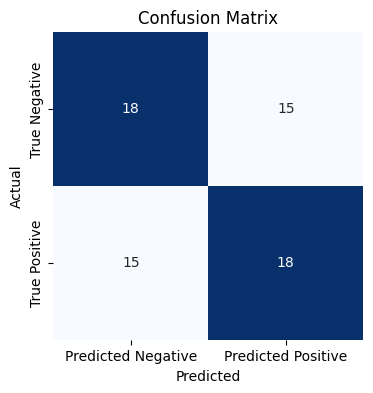

In [ ]:
acc, auc, sen, spc = evaluation(test_labels, aggre_preds)

In [ ]:
nn_acc.append(acc)
nn_auc.append(auc)
nn_sen.append(sen)
nn_spc.append(spc)

In [ ]:
print(nn_acc)
print(nn_auc)
print(nn_sen)
print(nn_spc)

[0.5454545454545454]
[np.float64(0.5454545454545454)]
[np.float64(0.5454545454545454)]
[np.float64(0.5454545454545454)]


# Round 2
random state 0

In [ ]:
# Splitting data
train_set, test_set, train_labels, test_labels = balanced_train_test_split(orig_data, orig_labels, drugs, 5, 0)

20 17
for drug  amikacin # of train samples:  27
for drug  amikacin # of test samples:  10
8 29
for drug  levofloxacin # of train samples:  29
for drug  levofloxacin # of test samples:  8
27 12
for drug  imipenem # of train samples:  29
for drug  imipenem # of test samples:  10
11 4
for drug  doripenem # of train samples:  11
for drug  doripenem # of test samples:  4
6 30
for drug  gentamicin # of train samples:  30
for drug  gentamicin # of test samples:  6
2 39
for drug  cefotaxime # of train samples:  39
for drug  cefotaxime # of test samples:  2
14 34
for drug  tetracycline # of train samples:  38
for drug  tetracycline # of test samples:  10
7 49
for drug  ciprofloxacin # of train samples:  50
for drug  ciprofloxacin # of test samples:  6
4 35
for drug  ceftazidime # of train samples:  35
for drug  ceftazidime # of test samples:  4
14 6
for drug  meropenem # of train samples:  14
for drug  meropenem # of test samples:  6


In [ ]:
triplet, pairedLabels =  make_balanced_triplets(train_set, train_labels, drugs, 400)

In [ ]:
train_labels = np.asarray(train_labels)
pairedLabels = np.asarray(pairedLabels)

### Training

#### Random Forest (RF)

In [ ]:
model = RandomForestClassifier(n_estimators=100).fit(train_set, train_labels[:, 1])
predict_RF = model.predict(test_set)

#### SVM

In [ ]:
model = SVC(kernel='poly').fit(train_set, train_labels[:, 1])
predict_SVM = model.predict(test_set)

#### XGBoost

In [ ]:
model = xgboost.XGBClassifier().fit(train_set, train_labels[:, 1])
predict_XGB = model.predict(test_set)

#### Triplet NN

In [ ]:
input_shape1 = (96,)
input_shape2 = (96,)
input_shape3 = (881,)

In [ ]:
siamese_net = create_siamese_model(input_shape1, input_shape2, input_shape3)

In [ ]:
triplet = np.asarray(triplet)

In [ ]:
triplet.shape

(5008, 1073)

In [ ]:
pairedLabels = np.asarray(pairedLabels)

In [ ]:
pairedLabels.shape

(5008, 2)

In [ ]:
num_epochs=10
history=History()
siamese_net = create_siamese_model(input_shape1, input_shape2, input_shape3)

print("Round: 1 ---> 1-10")
history = siamese_net.fit([[triplet[:, :96],
                           triplet[:, 96:(96+96)]],
                           triplet[:, (96+96):]], pairedLabels[:, 0],
                          epochs=num_epochs, batch_size=64, verbose=1, callbacks=history)

for i in range(20-1):
  print("Round: ", i+2, '--->', (i+1)*10+1, '-', (i+2)*10)

  triplet, pairedLabels =  make_balanced_triplets(train_set, train_labels, drugs, 400)

  history = siamese_net.fit([[triplet[:, :96],
                           triplet[:, 96:(96+96)]],
                           triplet[:, (96+96):]], pairedLabels[:, 0],
                          epochs=num_epochs, batch_size=64, verbose=1, callbacks=history)


In [ ]:
train_pred = siamese_net.predict([[triplet[:, :96],
                           triplet[:, 96:(96+96)]],
                           triplet[:, (96+96):]])

Accuracy:  0.9323083067092651
ROC-AUC:  0.8883014125618132
Sensitivity:  0.9676342152581556
Specificity:  0.8089686098654708


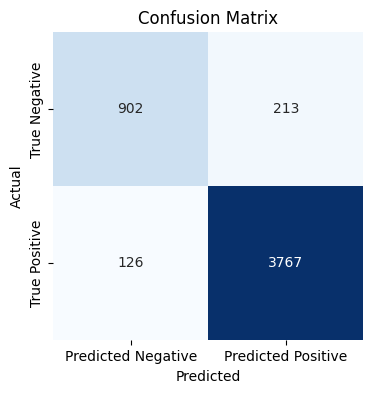

(0.9323083067092651,
 np.float64(0.8883014125618132),
 np.float64(0.9676342152581556),
 np.float64(0.8089686098654708))

In [ ]:
# Similarity test for train_set
evaluation(pairedLabels[:, 0], train_pred)

## Validation

#### RF

In [ ]:
test_labels = np.asarray(test_labels)

Accuracy:  0.5151515151515151
ROC-AUC:  0.5151515151515151
Sensitivity:  0.8181818181818182
Specificity:  0.21212121212121213


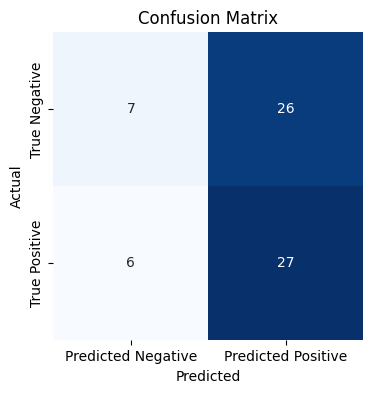

In [ ]:
acc, auc, sen, spc = evaluation(test_labels[:, 1], predict_RF)

In [ ]:
rf_acc.append(acc)
rf_auc.append(auc)
rf_sen.append(sen)
rf_spc.append(spc)

In [ ]:
print(rf_acc)
print(rf_auc)
print(rf_sen)
print(rf_spc)

[0.45454545454545453, 0.5151515151515151]
[np.float64(0.4545454545454546), np.float64(0.5151515151515151)]
[np.float64(0.8181818181818182), np.float64(0.8181818181818182)]
[np.float64(0.09090909090909091), np.float64(0.21212121212121213)]


#### SVM

Accuracy:  0.5
ROC-AUC:  0.5
Sensitivity:  1.0
Specificity:  0.0


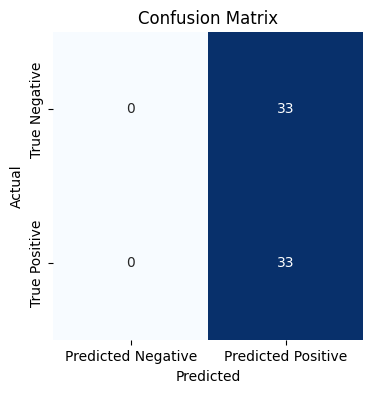

In [ ]:
acc, auc, sen, spc = evaluation(test_labels[:, 1], predict_SVM)

In [ ]:
svm_acc.append(acc)
svm_auc.append(auc)
svm_sen.append(sen)
svm_spc.append(spc)

In [ ]:
print(svm_acc)
print(svm_auc)
print(svm_sen)
print(svm_spc)

[0.5, 0.5]
[np.float64(0.5), np.float64(0.5)]
[np.float64(1.0), np.float64(1.0)]
[np.float64(0.0), np.float64(0.0)]


#### XGBoost

Accuracy:  0.4696969696969697
ROC-AUC:  0.4696969696969697
Sensitivity:  0.696969696969697
Specificity:  0.24242424242424243


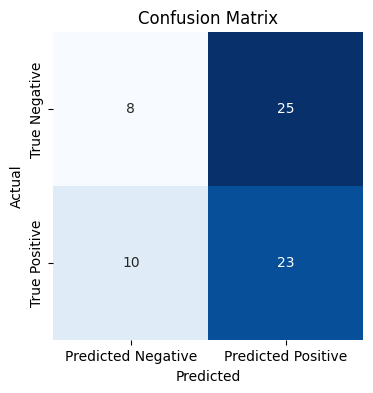

In [ ]:
acc, auc, sen, spc = evaluation(test_labels[:, 1], predict_XGB)

In [ ]:
xgb_acc.append(acc)
xgb_auc.append(auc)
xgb_sen.append(sen)
xgb_spc.append(spc)

In [ ]:
print(xgb_acc)
print(xgb_auc)
print(xgb_sen)
print(xgb_spc)

[0.4696969696969697, 0.4696969696969697]
[np.float64(0.4696969696969697), np.float64(0.4696969696969697)]
[np.float64(0.8181818181818182), np.float64(0.696969696969697)]
[np.float64(0.12121212121212122), np.float64(0.24242424242424243)]


#### Triplet NN

In [ ]:
test_labels = np.asarray(test_labels)
train_labels = np.asarray(train_labels)

In [ ]:
# splitting external_test_set to set of susceptible and resistant ones:
x0_test, x1_test = RS_splitter(test_set, test_labels[:, 1])

In [ ]:
print(len(x0_test))
print(len(x0_test[0]))
print(len(x1_test))
print(len(x1_test[0]))

33
977
33
977


In [ ]:
x0_train, x1_train = RS_splitter(train_set, train_labels[:, 1])

In [ ]:
print(len(x0_train))
print(len(x0_train[0]))
print(len(x1_train))
print(len(x1_train[0]))

80
977
222
977


In [ ]:
x0_train = np.asarray(x0_train)
x1_train = np.asarray(x1_train)

In [ ]:
test_labels = []  # True labels for test samples.
aggre_preds = [] # Aggregated pred values for each sample, by DefineTest2 func.
internal_labels = [] # Labels form ExternalTest2 for internal test
internal_preds = [] # internal_labels corresponding predictions


for i in x0_test:                     #x0_test, x1_test, x0_train, x1_train
  data, labels, indexSample = ExternalTest([i], [], x0_train, x1_train) # makes i couple with x0_train & x1_train
  internal_labels += labels.tolist()
  predd = siamese_net.predict([[data[:, :96],
                           data[:, 96:(96+96)]],
                           data[:, (96+96):]], verbose=0)
  internal_preds += [i[0] for i in predd.tolist()]
  y_pred, label = DefineTest2([i], [], indexSample, predd)
  aggre_preds.append(y_pred[0][0]) # y_pred ---> [array([0.5], dtype=float32)]
  test_labels.append(label[0])


for i in x1_test:
  data, labels, indexSample = ExternalTest([], [i], x0_train, x1_train)
  internal_labels += labels.tolist()
  predd = siamese_net.predict([[data[:, :96],
                           data[:, 96:(96+96)]],
                           data[:, (96+96):]], verbose=0)
  internal_preds += [i[0] for i in predd.tolist()]
  y_pred, label = DefineTest2([], [i], indexSample, predd)
  aggre_preds.append(y_pred[0][0])
  test_labels.append(label[0])

##### TSA_Net evaluation

(Similarity test)

Accuracy:  0.5391304347826087
ROC-AUC:  0.5358460355401877
Sensitivity:  0.8691159586681975
Specificity:  0.202576112412178


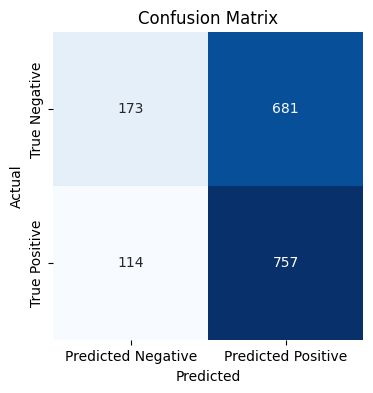

In [ ]:
acc, auc, sen, spc = evaluation(internal_labels, internal_preds)

In [ ]:
sim_acc.append(acc)
sim_auc.append(auc)
sim_sen.append(sen)
sim_spc.append(spc)

In [ ]:
print(sim_acc)
print(sim_auc)
print(sim_sen)
print(sim_spc)

[0.5121675155631012, 0.5391304347826087]
[np.float64(0.5014884233737597), np.float64(0.5358460355401877)]
[np.float64(0.9029768467475193), np.float64(0.8691159586681975)]
[np.float64(0.1), np.float64(0.202576112412178)]


##### TripSimAcin_AMR evaluation

(Phenotype prediction test)

Accuracy:  0.5
ROC-AUC:  0.5
Sensitivity:  0.21212121212121213
Specificity:  0.7878787878787878


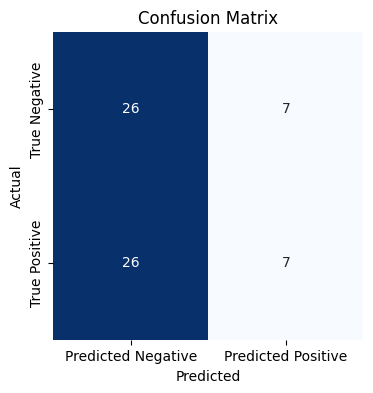

In [ ]:
acc, auc, sen, spc = evaluation(test_labels, aggre_preds)

In [ ]:
nn_acc.append(acc)
nn_auc.append(auc)
nn_sen.append(sen)
nn_spc.append(spc)

In [ ]:
print(nn_acc)
print(nn_auc)
print(nn_sen)
print(nn_spc)

[0.5454545454545454, 0.5]
[np.float64(0.5454545454545454), np.float64(0.5)]
[np.float64(0.5454545454545454), np.float64(0.21212121212121213)]
[np.float64(0.5454545454545454), np.float64(0.7878787878787878)]


# Round 3
random state: 123

In [ ]:
# Splitting data
train_set, test_set, train_labels, test_labels = balanced_train_test_split(orig_data, orig_labels, drugs, 5, 123)

20 17
for drug  amikacin # of train samples:  27
for drug  amikacin # of test samples:  10
8 29
for drug  levofloxacin # of train samples:  29
for drug  levofloxacin # of test samples:  8
27 12
for drug  imipenem # of train samples:  29
for drug  imipenem # of test samples:  10
11 4
for drug  doripenem # of train samples:  11
for drug  doripenem # of test samples:  4
6 30
for drug  gentamicin # of train samples:  30
for drug  gentamicin # of test samples:  6
2 39
for drug  cefotaxime # of train samples:  39
for drug  cefotaxime # of test samples:  2
14 34
for drug  tetracycline # of train samples:  38
for drug  tetracycline # of test samples:  10
7 49
for drug  ciprofloxacin # of train samples:  50
for drug  ciprofloxacin # of test samples:  6
4 35
for drug  ceftazidime # of train samples:  35
for drug  ceftazidime # of test samples:  4
14 6
for drug  meropenem # of train samples:  14
for drug  meropenem # of test samples:  6


In [ ]:
triplet, pairedLabels =  make_balanced_triplets(train_set, train_labels, drugs, 400)

In [ ]:
train_labels = np.asarray(train_labels)
pairedLabels = np.asarray(pairedLabels)

### Training

#### Random Forest (RF)

In [ ]:
model = RandomForestClassifier(n_estimators=100).fit(train_set, train_labels[:, 1])
predict_RF = model.predict(test_set)

#### SVM

In [ ]:
model = SVC(kernel='poly').fit(train_set, train_labels[:, 1])
predict_SVM = model.predict(test_set)

#### XGBoost

In [ ]:
model = xgboost.XGBClassifier().fit(train_set, train_labels[:, 1])
predict_XGB = model.predict(test_set)

#### Triplet NN

In [ ]:
input_shape1 = (96,)
input_shape2 = (96,)
input_shape3 = (881,)

In [ ]:
siamese_net = create_siamese_model(input_shape1, input_shape2, input_shape3)

In [ ]:
triplet = np.asarray(triplet)

In [ ]:
triplet.shape

(5008, 1073)

In [ ]:
pairedLabels = np.asarray(pairedLabels)

In [ ]:
pairedLabels.shape

(5008, 2)

In [ ]:
num_epochs=10
history=History()
siamese_net = create_siamese_model(input_shape1, input_shape2, input_shape3)

print("Round: 1 ---> 1-10")
history = siamese_net.fit([[triplet[:, :96],
                           triplet[:, 96:(96+96)]],
                           triplet[:, (96+96):]], pairedLabels[:, 0],
                          epochs=num_epochs, batch_size=64, verbose=1, callbacks=history)

for i in range(20-1):
  print("Round: ", i+2, '--->', (i+1)*10+1, '-', (i+2)*10)

  triplet, pairedLabels =  make_balanced_triplets(train_set, train_labels, drugs, 400)

  history = siamese_net.fit([[triplet[:, :96],
                           triplet[:, 96:(96+96)]],
                           triplet[:, (96+96):]], pairedLabels[:, 0],
                          epochs=num_epochs, batch_size=64, verbose=1, callbacks=history)

In [ ]:
train_pred = siamese_net.predict([[triplet[:, :96],
                           triplet[:, 96:(96+96)]],
                           triplet[:, (96+96):]])

Accuracy:  0.9333067092651757
ROC-AUC:  0.8876636114723565
Sensitivity:  0.9699460570254302
Specificity:  0.8053811659192825


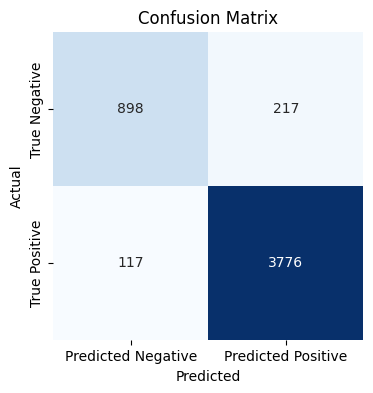

(0.9333067092651757,
 np.float64(0.8876636114723565),
 np.float64(0.9699460570254302),
 np.float64(0.8053811659192825))

In [ ]:
# Similarity test for train_set
evaluation(pairedLabels[:, 0], train_pred)

## Validation

#### RF

In [ ]:
test_labels = np.asarray(test_labels)

Accuracy:  0.4696969696969697
ROC-AUC:  0.4696969696969696
Sensitivity:  0.7878787878787878
Specificity:  0.15151515151515152


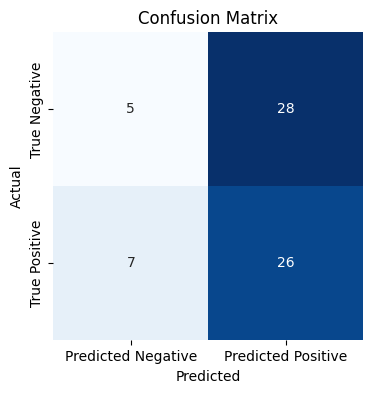

In [ ]:
acc, auc, sen, spc = evaluation(test_labels[:, 1], predict_RF)

In [ ]:
rf_acc.append(acc)
rf_auc.append(auc)
rf_sen.append(sen)
rf_spc.append(spc)

In [ ]:
print(rf_acc)
print(rf_auc)
print(rf_sen)
print(rf_spc)

[0.45454545454545453, 0.5151515151515151, 0.4696969696969697]
[np.float64(0.4545454545454546), np.float64(0.5151515151515151), np.float64(0.4696969696969696)]
[np.float64(0.8181818181818182), np.float64(0.8181818181818182), np.float64(0.7878787878787878)]
[np.float64(0.09090909090909091), np.float64(0.21212121212121213), np.float64(0.15151515151515152)]


#### SVM

Accuracy:  0.5
ROC-AUC:  0.5
Sensitivity:  1.0
Specificity:  0.0


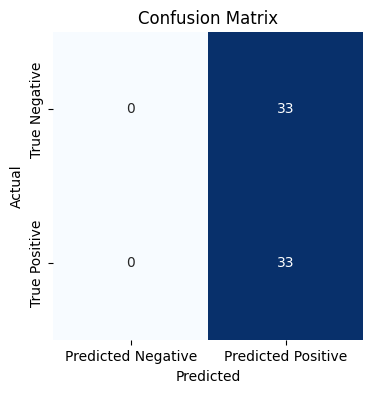

In [ ]:
acc, auc, sen, spc = evaluation(test_labels[:, 1], predict_SVM)

In [ ]:
svm_acc.append(acc)
svm_auc.append(auc)
svm_sen.append(sen)
svm_spc.append(spc)

In [ ]:
print(svm_acc)
print(svm_auc)
print(svm_sen)
print(svm_spc)

[0.5, 0.5, 0.5]
[np.float64(0.5), np.float64(0.5), np.float64(0.5)]
[np.float64(1.0), np.float64(1.0), np.float64(1.0)]
[np.float64(0.0), np.float64(0.0), np.float64(0.0)]


#### XGBoost

Accuracy:  0.5151515151515151
ROC-AUC:  0.5151515151515151
Sensitivity:  0.8484848484848485
Specificity:  0.18181818181818182


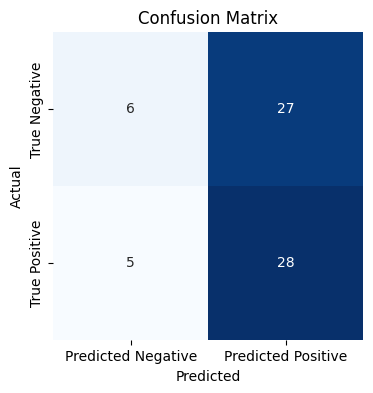

In [ ]:
acc, auc, sen, spc = evaluation(test_labels[:, 1], predict_XGB)

In [ ]:
xgb_acc.append(acc)
xgb_auc.append(auc)
xgb_sen.append(sen)
xgb_spc.append(spc)

In [ ]:
print(xgb_acc)
print(xgb_auc)
print(xgb_sen)
print(xgb_spc)

[0.4696969696969697, 0.4696969696969697, 0.5151515151515151]
[np.float64(0.4696969696969697), np.float64(0.4696969696969697), np.float64(0.5151515151515151)]
[np.float64(0.8181818181818182), np.float64(0.696969696969697), np.float64(0.8484848484848485)]
[np.float64(0.12121212121212122), np.float64(0.24242424242424243), np.float64(0.18181818181818182)]


#### Triplet NN

In [ ]:
test_labels = np.asarray(test_labels)
train_labels = np.asarray(train_labels)

In [ ]:
# splitting external_test_set to set of susceptible and resistant ones:
x0_test, x1_test = RS_splitter(test_set, test_labels[:, 1])

In [ ]:
print(len(x0_test))
print(len(x0_test[0]))
print(len(x1_test))
print(len(x1_test[0]))

33
977
33
977


In [ ]:
x0_train, x1_train = RS_splitter(train_set, train_labels[:, 1])

In [ ]:
print(len(x0_train))
print(len(x0_train[0]))
print(len(x1_train))
print(len(x1_train[0]))

80
977
222
977


In [ ]:
x0_train = np.asarray(x0_train)
x1_train = np.asarray(x1_train)

In [ ]:
test_labels = []  # True labels for test samples.
aggre_preds = [] # Aggregated pred values for each sample, by DefineTest2 func.
internal_labels = [] # Labels form ExternalTest2 for internal test
internal_preds = [] # internal_labels corresponding predictions


for i in x0_test:                     #x0_test, x1_test, x0_train, x1_train
  data, labels, indexSample = ExternalTest([i], [], x0_train, x1_train) # makes i couple with x0_train & x1_train
  internal_labels += labels.tolist()
  predd = siamese_net.predict([[data[:, :96],
                           data[:, 96:(96+96)]],
                           data[:, (96+96):]], verbose=0)
  internal_preds += [i[0] for i in predd.tolist()]
  y_pred, label = DefineTest2([i], [], indexSample, predd)
  aggre_preds.append(y_pred[0][0]) # y_pred ---> [array([0.5], dtype=float32)]
  test_labels.append(label[0])


for i in x1_test:
  data, labels, indexSample = ExternalTest([], [i], x0_train, x1_train)
  internal_labels += labels.tolist()
  predd = siamese_net.predict([[data[:, :96],
                           data[:, 96:(96+96)]],
                           data[:, (96+96):]], verbose=0)
  internal_preds += [i[0] for i in predd.tolist()]
  y_pred, label = DefineTest2([], [i], indexSample, predd)
  aggre_preds.append(y_pred[0][0])
  test_labels.append(label[0])

##### TSA_Net evaluation

(Similarity test)

Accuracy:  0.49138443256090314
ROC-AUC:  0.4887378544797198
Sensitivity:  0.8313679245283019
Specificity:  0.14610778443113773


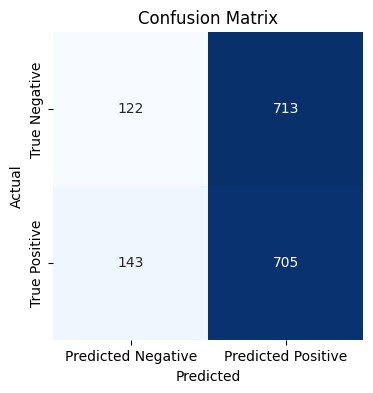

In [ ]:
acc, auc, sen, spc = evaluation(internal_labels, internal_preds)

In [ ]:
sim_acc.append(acc)
sim_auc.append(auc)
sim_sen.append(sen)
sim_spc.append(spc)

In [ ]:
print(sim_acc)
print(sim_auc)
print(sim_sen)
print(sim_spc)

[0.5121675155631012, 0.5391304347826087, 0.49138443256090314]
[np.float64(0.5014884233737597), np.float64(0.5358460355401877), np.float64(0.4887378544797198)]
[np.float64(0.9029768467475193), np.float64(0.8691159586681975), np.float64(0.8313679245283019)]
[np.float64(0.1), np.float64(0.202576112412178), np.float64(0.14610778443113773)]


##### TripSimAcin_AMR evaluation

(Phenotype prediction test)

Accuracy:  0.3939393939393939
ROC-AUC:  0.3939393939393939
Sensitivity:  0.30303030303030304
Specificity:  0.48484848484848486


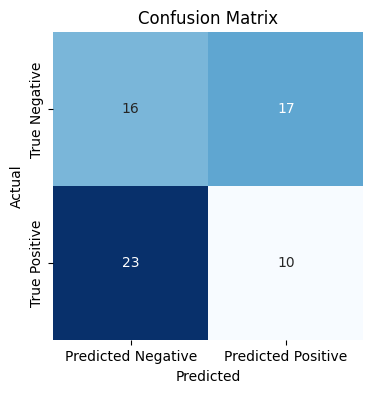

In [ ]:
acc, auc, sen, spc = evaluation(test_labels, aggre_preds)

In [ ]:
nn_acc.append(acc)
nn_auc.append(auc)
nn_sen.append(sen)
nn_spc.append(spc)

In [ ]:
print(nn_acc)
print(nn_auc)
print(nn_sen)
print(nn_spc)

[0.5454545454545454, 0.5, 0.3939393939393939]
[np.float64(0.5454545454545454), np.float64(0.5), np.float64(0.3939393939393939)]
[np.float64(0.5454545454545454), np.float64(0.21212121212121213), np.float64(0.30303030303030304)]
[np.float64(0.5454545454545454), np.float64(0.7878787878787878), np.float64(0.48484848484848486)]


# Round 4
random state: 777

In [ ]:
# Splitting data
train_set, test_set, train_labels, test_labels = balanced_train_test_split(orig_data, orig_labels, drugs, 5, 777)

20 17
for drug  amikacin # of train samples:  27
for drug  amikacin # of test samples:  10
8 29
for drug  levofloxacin # of train samples:  29
for drug  levofloxacin # of test samples:  8
27 12
for drug  imipenem # of train samples:  29
for drug  imipenem # of test samples:  10
11 4
for drug  doripenem # of train samples:  11
for drug  doripenem # of test samples:  4
6 30
for drug  gentamicin # of train samples:  30
for drug  gentamicin # of test samples:  6
2 39
for drug  cefotaxime # of train samples:  39
for drug  cefotaxime # of test samples:  2
14 34
for drug  tetracycline # of train samples:  38
for drug  tetracycline # of test samples:  10
7 49
for drug  ciprofloxacin # of train samples:  50
for drug  ciprofloxacin # of test samples:  6
4 35
for drug  ceftazidime # of train samples:  35
for drug  ceftazidime # of test samples:  4
14 6
for drug  meropenem # of train samples:  14
for drug  meropenem # of test samples:  6


In [ ]:
triplet, pairedLabels =  make_balanced_triplets(train_set, train_labels, drugs, 400)

In [ ]:
train_labels = np.asarray(train_labels)
pairedLabels = np.asarray(pairedLabels)

### Training

#### Random Forest (RF)

In [ ]:
model = RandomForestClassifier(n_estimators=100).fit(train_set, train_labels[:, 1])
predict_RF = model.predict(test_set)

#### SVM

In [ ]:
model = SVC(kernel='poly').fit(train_set, train_labels[:, 1])
predict_SVM = model.predict(test_set)

#### XGBoost

In [ ]:
model = xgboost.XGBClassifier().fit(train_set, train_labels[:, 1])
predict_XGB = model.predict(test_set)

#### Triplet NN

In [ ]:
input_shape1 = (96,)
input_shape2 = (96,)
input_shape3 = (881,)

In [ ]:
siamese_net = create_siamese_model(input_shape1, input_shape2, input_shape3)

In [ ]:
triplet = np.asarray(triplet)

In [ ]:
triplet.shape

(5008, 1073)

In [ ]:
pairedLabels = np.asarray(pairedLabels)

In [ ]:
pairedLabels.shape

(5008, 2)

In [ ]:
num_epochs=10
history=History()
siamese_net = create_siamese_model(input_shape1, input_shape2, input_shape3)

print("Round: 1 ---> 1-10")
history = siamese_net.fit([[triplet[:, :96],
                           triplet[:, 96:(96+96)]],
                           triplet[:, (96+96):]], pairedLabels[:, 0],
                          epochs=num_epochs, batch_size=64, verbose=1, callbacks=history)

for i in range(20-1):
  print("Round: ", i+2, '--->', (i+1)*10+1, '-', (i+2)*10)

  triplet, pairedLabels =  make_balanced_triplets(train_set, train_labels, drugs, 400)

  history = siamese_net.fit([[triplet[:, :96],
                           triplet[:, 96:(96+96)]],
                           triplet[:, (96+96):]], pairedLabels[:, 0],
                          epochs=num_epochs, batch_size=64, verbose=1, callbacks=history)


In [ ]:
train_pred = siamese_net.predict([[triplet[:, :96],
                           triplet[:, 96:(96+96)]],
                           triplet[:, (96+96):]])

Accuracy:  0.919129392971246
ROC-AUC:  0.8574250206476152
Sensitivity:  0.9686617004880554
Specificity:  0.7461883408071749


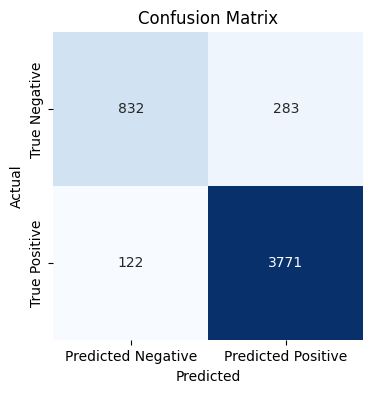

(0.919129392971246,
 np.float64(0.8574250206476152),
 np.float64(0.9686617004880554),
 np.float64(0.7461883408071749))

In [ ]:
# Similarity test for train_set
evaluation(pairedLabels[:, 0], train_pred)

## Validation

#### RF

In [ ]:
test_labels = np.asarray(test_labels)

Accuracy:  0.5151515151515151
ROC-AUC:  0.5151515151515151
Sensitivity:  0.9393939393939394
Specificity:  0.09090909090909091


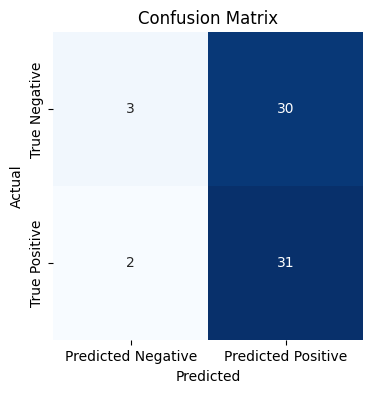

In [ ]:
acc, auc, sen, spc = evaluation(test_labels[:, 1], predict_RF)

In [ ]:
rf_acc.append(acc)
rf_auc.append(auc)
rf_sen.append(sen)
rf_spc.append(spc)

In [ ]:
print(rf_acc)
print(rf_auc)
print(rf_sen)
print(rf_spc)

[0.45454545454545453, 0.5151515151515151, 0.4696969696969697, 0.5151515151515151]
[np.float64(0.4545454545454546), np.float64(0.5151515151515151), np.float64(0.4696969696969696), np.float64(0.5151515151515151)]
[np.float64(0.8181818181818182), np.float64(0.8181818181818182), np.float64(0.7878787878787878), np.float64(0.9393939393939394)]
[np.float64(0.09090909090909091), np.float64(0.21212121212121213), np.float64(0.15151515151515152), np.float64(0.09090909090909091)]


#### SVM

Accuracy:  0.5
ROC-AUC:  0.5
Sensitivity:  1.0
Specificity:  0.0


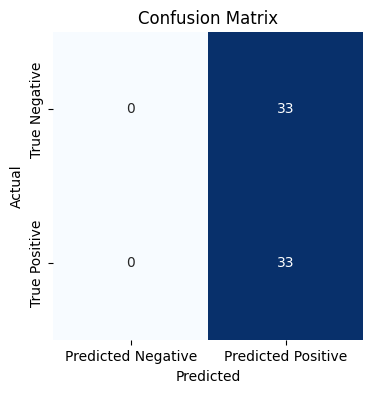

In [ ]:
acc, auc, sen, spc = evaluation(test_labels[:, 1], predict_SVM)

In [ ]:
svm_acc.append(acc)
svm_auc.append(auc)
svm_sen.append(sen)
svm_spc.append(spc)

In [ ]:
print(svm_acc)
print(svm_auc)
print(svm_sen)
print(svm_spc)

[0.5, 0.5, 0.5, 0.5]
[np.float64(0.5), np.float64(0.5), np.float64(0.5), np.float64(0.5)]
[np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]
[np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]


#### XGBoost

Accuracy:  0.5303030303030303
ROC-AUC:  0.5303030303030303
Sensitivity:  0.9090909090909091
Specificity:  0.15151515151515152


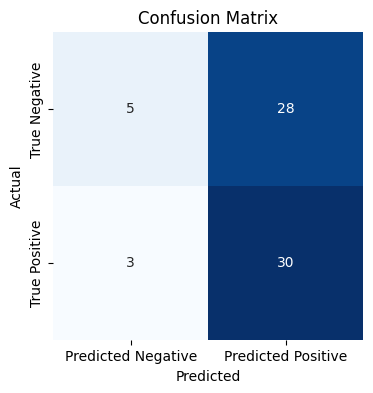

In [ ]:
acc, auc, sen, spc = evaluation(test_labels[:, 1], predict_XGB)

In [ ]:
xgb_acc.append(acc)
xgb_auc.append(auc)
xgb_sen.append(sen)
xgb_spc.append(spc)

In [ ]:
print(xgb_acc)
print(xgb_auc)
print(xgb_sen)
print(xgb_spc)

[0.4696969696969697, 0.4696969696969697, 0.5151515151515151, 0.5303030303030303]
[np.float64(0.4696969696969697), np.float64(0.4696969696969697), np.float64(0.5151515151515151), np.float64(0.5303030303030303)]
[np.float64(0.8181818181818182), np.float64(0.696969696969697), np.float64(0.8484848484848485), np.float64(0.9090909090909091)]
[np.float64(0.12121212121212122), np.float64(0.24242424242424243), np.float64(0.18181818181818182), np.float64(0.15151515151515152)]


#### Triplet NN

In [ ]:
test_labels = np.asarray(test_labels)
train_labels = np.asarray(train_labels)

In [ ]:
# splitting external_test_set to set of susceptible and resistant ones:
x0_test, x1_test = RS_splitter(test_set, test_labels[:, 1])

In [ ]:
print(len(x0_test))
print(len(x0_test[0]))
print(len(x1_test))
print(len(x1_test[0]))

33
977
33
977


In [ ]:
x0_train, x1_train = RS_splitter(train_set, train_labels[:, 1])

In [ ]:
print(len(x0_train))
print(len(x0_train[0]))
print(len(x1_train))
print(len(x1_train[0]))

80
977
222
977


In [ ]:
x0_train = np.asarray(x0_train)
x1_train = np.asarray(x1_train)

In [ ]:
test_labels = []  # True labels for test samples.
aggre_preds = [] # Aggregated pred values for each sample, by DefineTest2 func.
internal_labels = [] # Labels form ExternalTest2 for internal test
internal_preds = [] # internal_labels corresponding predictions


for i in x0_test:                     #x0_test, x1_test, x0_train, x1_train
  data, labels, indexSample = ExternalTest([i], [], x0_train, x1_train) # makes i couple with x0_train & x1_train
  internal_labels += labels.tolist()
  predd = siamese_net.predict([[data[:, :96],
                           data[:, 96:(96+96)]],
                           data[:, (96+96):]], verbose=0)
  internal_preds += [i[0] for i in predd.tolist()]
  y_pred, label = DefineTest2([i], [], indexSample, predd)
  aggre_preds.append(y_pred[0][0]) # y_pred ---> [array([0.5], dtype=float32)]
  test_labels.append(label[0])


for i in x1_test:
  data, labels, indexSample = ExternalTest([], [i], x0_train, x1_train)
  internal_labels += labels.tolist()
  predd = siamese_net.predict([[data[:, :96],
                           data[:, 96:(96+96)]],
                           data[:, (96+96):]], verbose=0)
  internal_preds += [i[0] for i in predd.tolist()]
  y_pred, label = DefineTest2([], [i], indexSample, predd)
  aggre_preds.append(y_pred[0][0])
  test_labels.append(label[0])

##### TSA_Net evaluation

(Similarity test)

Accuracy:  0.4988425925925926
ROC-AUC:  0.49562125643213784
Sensitivity:  0.8932261768082663
Specificity:  0.09801633605600933


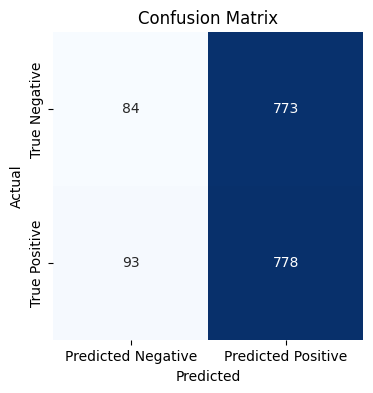

In [ ]:
acc, auc, sen, spc = evaluation(internal_labels, internal_preds)

In [ ]:
sim_acc.append(acc)
sim_auc.append(auc)
sim_sen.append(sen)
sim_spc.append(spc)

In [ ]:
print(sim_acc)
print(sim_auc)
print(sim_sen)
print(sim_spc)

[0.5121675155631012, 0.5391304347826087, 0.49138443256090314, 0.4988425925925926]
[np.float64(0.5014884233737597), np.float64(0.5358460355401877), np.float64(0.4887378544797198), np.float64(0.49562125643213784)]
[np.float64(0.9029768467475193), np.float64(0.8691159586681975), np.float64(0.8313679245283019), np.float64(0.8932261768082663)]
[np.float64(0.1), np.float64(0.202576112412178), np.float64(0.14610778443113773), np.float64(0.09801633605600933)]


##### TripSimAcin_AMR evaluation

(Phenotype prediction test)

Accuracy:  0.4393939393939394
ROC-AUC:  0.43939393939393934
Sensitivity:  0.6060606060606061
Specificity:  0.2727272727272727


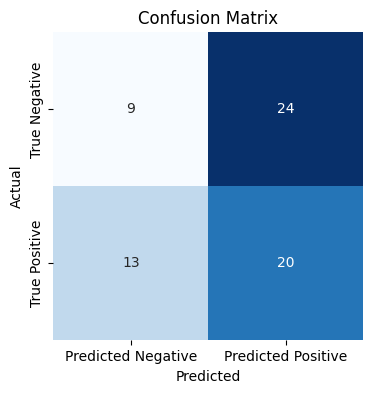

In [ ]:
acc, auc, sen, spc = evaluation(test_labels, aggre_preds)

In [ ]:
nn_acc.append(acc)
nn_auc.append(auc)
nn_sen.append(sen)
nn_spc.append(spc)

In [ ]:
print(nn_acc)
print(nn_auc)
print(nn_sen)
print(nn_spc)

[0.5454545454545454, 0.5, 0.3939393939393939, 0.4393939393939394]
[np.float64(0.5454545454545454), np.float64(0.5), np.float64(0.3939393939393939), np.float64(0.43939393939393934)]
[np.float64(0.5454545454545454), np.float64(0.21212121212121213), np.float64(0.30303030303030304), np.float64(0.6060606060606061)]
[np.float64(0.5454545454545454), np.float64(0.7878787878787878), np.float64(0.48484848484848486), np.float64(0.2727272727272727)]


# Round 5
random state: 111

In [ ]:
# Splitting data
train_set, test_set, train_labels, test_labels = balanced_train_test_split(orig_data, orig_labels, drugs, 5, 111)

20 17
for drug  amikacin # of train samples:  27
for drug  amikacin # of test samples:  10
8 29
for drug  levofloxacin # of train samples:  29
for drug  levofloxacin # of test samples:  8
27 12
for drug  imipenem # of train samples:  29
for drug  imipenem # of test samples:  10
11 4
for drug  doripenem # of train samples:  11
for drug  doripenem # of test samples:  4
6 30
for drug  gentamicin # of train samples:  30
for drug  gentamicin # of test samples:  6
2 39
for drug  cefotaxime # of train samples:  39
for drug  cefotaxime # of test samples:  2
14 34
for drug  tetracycline # of train samples:  38
for drug  tetracycline # of test samples:  10
7 49
for drug  ciprofloxacin # of train samples:  50
for drug  ciprofloxacin # of test samples:  6
4 35
for drug  ceftazidime # of train samples:  35
for drug  ceftazidime # of test samples:  4
14 6
for drug  meropenem # of train samples:  14
for drug  meropenem # of test samples:  6


In [ ]:
triplet, pairedLabels =  make_balanced_triplets(train_set, train_labels, drugs, 400)

In [ ]:
train_labels = np.asarray(train_labels)
pairedLabels = np.asarray(pairedLabels)

### Training

#### Random Forest (RF)

In [ ]:
model = RandomForestClassifier(n_estimators=100).fit(train_set, train_labels[:, 1])
predict_RF = model.predict(test_set)

#### SVM

In [ ]:
model = SVC(kernel='poly').fit(train_set, train_labels[:, 1])
predict_SVM = model.predict(test_set)

#### XGBoost

In [ ]:
model = xgboost.XGBClassifier().fit(train_set, train_labels[:, 1])
predict_XGB = model.predict(test_set)

#### Triplet NN

In [ ]:
input_shape1 = (96,)
input_shape2 = (96,)
input_shape3 = (881,)

In [ ]:
siamese_net = create_siamese_model(input_shape1, input_shape2, input_shape3)

In [ ]:
triplet = np.asarray(triplet)

In [ ]:
triplet.shape

(5008, 1073)

In [ ]:
pairedLabels = np.asarray(pairedLabels)

In [ ]:
pairedLabels.shape

(5008, 2)

In [ ]:
num_epochs=10
history=History()
siamese_net = create_siamese_model(input_shape1, input_shape2, input_shape3)

print("Round: 1 ---> 1-10")
history = siamese_net.fit([[triplet[:, :96],
                           triplet[:, 96:(96+96)]],
                           triplet[:, (96+96):]], pairedLabels[:, 0],
                          epochs=num_epochs, batch_size=64, verbose=1, callbacks=history)

for i in range(20-1):
  print("Round: ", i+2, '--->', (i+1)*10+1, '-', (i+2)*10)

  triplet, pairedLabels =  make_balanced_triplets(train_set, train_labels, drugs, 400)

  history = siamese_net.fit([[triplet[:, :96],
                           triplet[:, 96:(96+96)]],
                           triplet[:, (96+96):]], pairedLabels[:, 0],
                          epochs=num_epochs, batch_size=64, verbose=1, callbacks=history)

In [ ]:
train_pred = siamese_net.predict([[triplet[:, :96],
                           triplet[:, 96:(96+96)]],
                           triplet[:, (96+96):]])

Accuracy:  0.9221246006389776
ROC-AUC:  0.8667114367630068
Sensitivity:  0.9666067300282558
Specificity:  0.7668161434977578


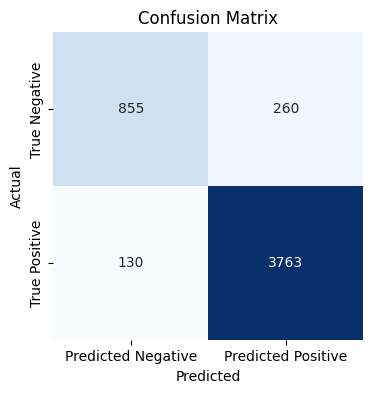

(0.9221246006389776,
 np.float64(0.8667114367630068),
 np.float64(0.9666067300282558),
 np.float64(0.7668161434977578))

In [ ]:
# Similarity test for train_set
evaluation(pairedLabels[:, 0], train_pred)

## Validation

#### RF

In [ ]:
test_labels = np.asarray(test_labels)

Accuracy:  0.5303030303030303
ROC-AUC:  0.5303030303030304
Sensitivity:  0.8181818181818182
Specificity:  0.24242424242424243


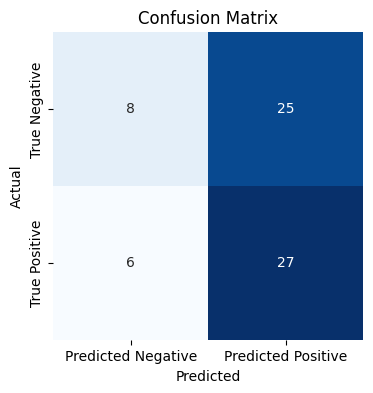

In [ ]:
acc, auc, sen, spc = evaluation(test_labels[:, 1], predict_RF)

In [ ]:
rf_acc.append(acc)
rf_auc.append(auc)
rf_sen.append(sen)
rf_spc.append(spc)

In [ ]:
print(rf_acc)
print(rf_auc)
print(rf_sen)
print(rf_spc)

[0.45454545454545453, 0.5151515151515151, 0.4696969696969697, 0.5151515151515151, 0.5303030303030303]
[np.float64(0.4545454545454546), np.float64(0.5151515151515151), np.float64(0.4696969696969696), np.float64(0.5151515151515151), np.float64(0.5303030303030304)]
[np.float64(0.8181818181818182), np.float64(0.8181818181818182), np.float64(0.7878787878787878), np.float64(0.9393939393939394), np.float64(0.8181818181818182)]
[np.float64(0.09090909090909091), np.float64(0.21212121212121213), np.float64(0.15151515151515152), np.float64(0.09090909090909091), np.float64(0.24242424242424243)]


#### SVM

Accuracy:  0.5
ROC-AUC:  0.5
Sensitivity:  1.0
Specificity:  0.0


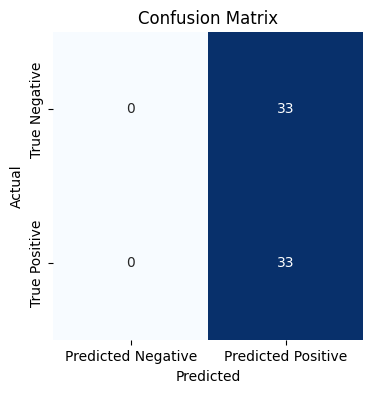

In [ ]:
acc, auc, sen, spc = evaluation(test_labels[:, 1], predict_SVM)

In [ ]:
svm_acc.append(acc)
svm_auc.append(auc)
svm_sen.append(sen)
svm_spc.append(spc)

In [ ]:
print(svm_acc)
print(svm_auc)
print(svm_sen)
print(svm_spc)

[0.5, 0.5, 0.5, 0.5, 0.5]
[np.float64(0.5), np.float64(0.5), np.float64(0.5), np.float64(0.5), np.float64(0.5)]
[np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]
[np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]


#### XGBoost

Accuracy:  0.5
ROC-AUC:  0.5
Sensitivity:  0.8484848484848485
Specificity:  0.15151515151515152


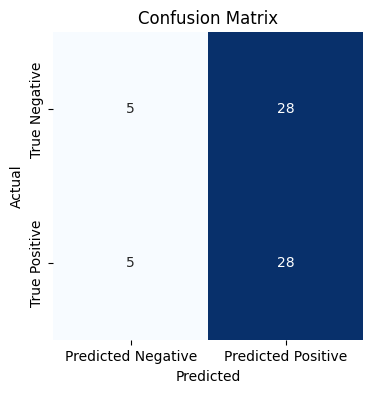

In [ ]:
acc, auc, sen, spc = evaluation(test_labels[:, 1], predict_XGB)

In [ ]:
xgb_acc.append(acc)
xgb_auc.append(auc)
xgb_sen.append(sen)
xgb_spc.append(spc)

In [ ]:
print(xgb_acc)
print(xgb_auc)
print(xgb_sen)
print(xgb_spc)

[0.4696969696969697, 0.4696969696969697, 0.5151515151515151, 0.5303030303030303, 0.5]
[np.float64(0.4696969696969697), np.float64(0.4696969696969697), np.float64(0.5151515151515151), np.float64(0.5303030303030303), np.float64(0.5)]
[np.float64(0.8181818181818182), np.float64(0.696969696969697), np.float64(0.8484848484848485), np.float64(0.9090909090909091), np.float64(0.8484848484848485)]
[np.float64(0.12121212121212122), np.float64(0.24242424242424243), np.float64(0.18181818181818182), np.float64(0.15151515151515152), np.float64(0.15151515151515152)]


#### Triplet NN

In [ ]:
test_labels = np.asarray(test_labels)
train_labels = np.asarray(train_labels)

In [ ]:
# splitting external_test_set to set of susceptible and resistant ones:
x0_test, x1_test = RS_splitter(test_set, test_labels[:, 1])

In [ ]:
print(len(x0_test))
print(len(x0_test[0]))
print(len(x1_test))
print(len(x1_test[0]))

33
977
33
977


In [ ]:
x0_train, x1_train = RS_splitter(train_set, train_labels[:, 1])

In [ ]:
print(len(x0_train))
print(len(x0_train[0]))
print(len(x1_train))
print(len(x1_train[0]))

80
977
222
977


In [ ]:
x0_train = np.asarray(x0_train)
x1_train = np.asarray(x1_train)

In [ ]:
test_labels = []  # True labels for test samples.
aggre_preds = [] # Aggregated pred values for each sample, by DefineTest2 func.
internal_labels = [] # Labels form ExternalTest2 for internal test
internal_preds = [] # internal_labels corresponding predictions


for i in x0_test:                     #x0_test, x1_test, x0_train, x1_train
  data, labels, indexSample = ExternalTest([i], [], x0_train, x1_train) # makes i couple with x0_train & x1_train
  internal_labels += labels.tolist()
  predd = siamese_net.predict([[data[:, :96],
                           data[:, 96:(96+96)]],
                           data[:, (96+96):]], verbose=0)
  internal_preds += [i[0] for i in predd.tolist()]
  y_pred, label = DefineTest2([i], [], indexSample, predd)
  aggre_preds.append(y_pred[0][0]) # y_pred ---> [array([0.5], dtype=float32)]
  test_labels.append(label[0])


for i in x1_test:
  data, labels, indexSample = ExternalTest([], [i], x0_train, x1_train)
  internal_labels += labels.tolist()
  predd = siamese_net.predict([[data[:, :96],
                           data[:, 96:(96+96)]],
                           data[:, (96+96):]], verbose=0)
  internal_preds += [i[0] for i in predd.tolist()]
  y_pred, label = DefineTest2([], [i], indexSample, predd)
  aggre_preds.append(y_pred[0][0])
  test_labels.append(label[0])

##### TSA_Net evaluation

(Similarity test)

Accuracy:  0.4948512585812357
ROC-AUC:  0.48457411133467476
Sensitivity:  0.8928571428571429
Specificity:  0.07629107981220658


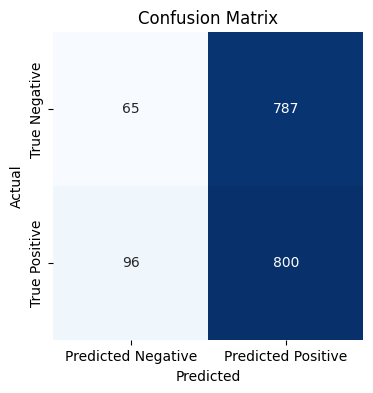

In [ ]:
acc, auc, sen, spc = evaluation(internal_labels, internal_preds)

In [ ]:
sim_acc.append(acc)
sim_auc.append(auc)
sim_sen.append(sen)
sim_spc.append(spc)

In [ ]:
print(sim_acc)
print(sim_auc)
print(sim_sen)
print(sim_spc)

[0.5121675155631012, 0.5391304347826087, 0.49138443256090314, 0.4988425925925926, 0.4948512585812357]
[np.float64(0.5014884233737597), np.float64(0.5358460355401877), np.float64(0.4887378544797198), np.float64(0.49562125643213784), np.float64(0.48457411133467476)]
[np.float64(0.9029768467475193), np.float64(0.8691159586681975), np.float64(0.8313679245283019), np.float64(0.8932261768082663), np.float64(0.8928571428571429)]
[np.float64(0.1), np.float64(0.202576112412178), np.float64(0.14610778443113773), np.float64(0.09801633605600933), np.float64(0.07629107981220658)]


##### TripSimAcin_AMR evaluation

(Phenotype prediction test)

Accuracy:  0.5151515151515151
ROC-AUC:  0.5151515151515152
Sensitivity:  0.36363636363636365
Specificity:  0.6666666666666666


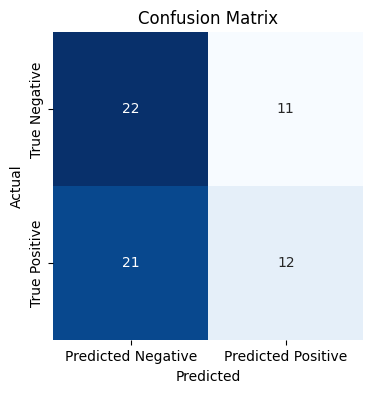

In [ ]:
acc, auc, sen, spc = evaluation(test_labels, aggre_preds)

In [ ]:
nn_acc.append(acc)
nn_auc.append(auc)
nn_sen.append(sen)
nn_spc.append(spc)

In [ ]:
print(nn_acc)
print(nn_auc)
print(nn_sen)
print(nn_spc)

[0.5454545454545454, 0.5, 0.3939393939393939, 0.4393939393939394, 0.5151515151515151]
[np.float64(0.5454545454545454), np.float64(0.5), np.float64(0.3939393939393939), np.float64(0.43939393939393934), np.float64(0.5151515151515152)]
[np.float64(0.5454545454545454), np.float64(0.21212121212121213), np.float64(0.30303030303030304), np.float64(0.6060606060606061), np.float64(0.36363636363636365)]
[np.float64(0.5454545454545454), np.float64(0.7878787878787878), np.float64(0.48484848484848486), np.float64(0.2727272727272727), np.float64(0.6666666666666666)]


# Results

## RF

In [ ]:
print("Average accuracy: ", sum(rf_acc)/len(rf_acc))
print("Average AUC: ", sum(rf_auc)/len(rf_auc))
print("Average sensitivity: ", sum(rf_sen)/len(rf_sen))
print("Average specificity: ", sum(rf_spc)/len(rf_spc))

Average accuracy:  0.49696969696969695
Average AUC:  0.49696969696969695
Average sensitivity:  0.8363636363636363
Average specificity:  0.1575757575757576


## SVM

In [ ]:
print("Average accuracy: ", sum(svm_acc)/len(svm_acc))
print("Average AUC: ", sum(svm_auc)/len(svm_auc))
print("Average sensitivity: ", sum(svm_sen)/len(svm_sen))
print("Average specificity: ", sum(svm_spc)/len(svm_spc))

Average accuracy:  0.5
Average AUC:  0.5
Average sensitivity:  1.0
Average specificity:  0.0


## XGB

In [ ]:
print("Average accuracy: ", sum(xgb_acc)/len(xgb_acc))
print("Average AUC: ", sum(xgb_auc)/len(xgb_auc))
print("Average sensitivity: ", sum(xgb_sen)/len(xgb_sen))
print("Average specificity: ", sum(xgb_spc)/len(xgb_spc))

Average accuracy:  0.49696969696969695
Average AUC:  0.49696969696969695
Average sensitivity:  0.8242424242424242
Average specificity:  0.16969696969696968


## TripSimAcin_AMR

In [ ]:
print("Average accuracy: ", sum(nn_acc)/len(nn_acc))
print("Average AUC: ", sum(nn_auc)/len(nn_auc))
print("Average sensitivity: ", sum(nn_sen)/len(nn_sen))
print("Average specificity: ", sum(nn_spc)/len(nn_spc))

Average accuracy:  0.4787878787878788
Average AUC:  0.4787878787878788
Average sensitivity:  0.40606060606060607
Average specificity:  0.5515151515151515


## TSA_Net

In [ ]:
print("Average accuracy: ", sum(sim_acc)/len(sim_acc))
print("Average AUC: ", sum(sim_auc)/len(sim_auc))
print("Average sensitivity: ", sum(sim_sen)/len(sim_sen))
print("Average specificity: ", sum(sim_spc)/len(sim_spc))

Average accuracy:  0.5072752468160883
Average AUC:  0.501253536232096
Average sensitivity:  0.8779088099218857
Average specificity:  0.12459826254230633


In [ ]:
avg_acc = [sum(rf_acc)/len(rf_acc), sum(svm_acc)/len(svm_acc), sum(xgb_acc)/len(xgb_acc), sum(nn_acc)/len(nn_acc)]
print(avg_acc)

[0.49696969696969695, 0.5, 0.49696969696969695, 0.4787878787878788]


In [ ]:
avg_auc = [sum(rf_auc)/len(rf_auc), sum(svm_auc)/len(svm_auc), sum(xgb_auc)/len(xgb_auc), sum(nn_auc)/len(nn_auc)]
print(avg_auc)

[np.float64(0.49696969696969695), np.float64(0.5), np.float64(0.49696969696969695), np.float64(0.4787878787878788)]


In [ ]:
avg_sen = [sum(rf_sen)/len(rf_sen), sum(svm_sen)/len(svm_sen), sum(xgb_sen)/len(xgb_sen), sum(nn_sen)/len(nn_sen)]
print(avg_sen)

[np.float64(0.8363636363636363), np.float64(1.0), np.float64(0.8242424242424242), np.float64(0.40606060606060607)]


In [ ]:
avg_spc = [sum(rf_spc)/len(rf_spc), sum(svm_spc)/len(svm_spc), sum(xgb_spc)/len(xgb_spc), sum(nn_spc)/len(nn_spc)]
print(avg_spc)

[np.float64(0.1575757575757576), np.float64(0.0), np.float64(0.16969696969696968), np.float64(0.5515151515151515)]


In [ ]:
import pandas as pd

data = [avg_acc, avg_auc, avg_sen, avg_spc]

results = pd.DataFrame(data, columns=['RF', 'SVM', 'XGB', 'NN'], index=['ACC', 'AUC', 'SEN', 'SPC'])

results

,RF,SVM,XGB,NN
ACC,0.496970,0.5,0.496970,0.478788
AUC,0.496970,0.5,0.496970,0.478788
SEN,0.836364,1.0,0.824242,0.406061
SPC,0.157576,0.0,0.169697,0.551515
